# Taxonomy Validation: Overlap Detection

**Purpose**: Validate `taxonomy_sheet_v2.csv` for keyword overlaps before running the expansion pipeline (notebooks 11-13).

**What this notebook does:**
1. Load and parse taxonomy with multi-line keywords
2. Detect exact keyword overlaps between categories
3. Detect semantic similarity overlaps using embeddings
4. Generate comprehensive overlap report
5. Export cleaned taxonomy (if changes are made)

**Why this matters:**
- Overlapping seed keywords → overlapping expanded synonyms → muddy category boundaries
- Clean taxonomy = better classification performance
- Include/exclude criteria help resolve edge cases

## Setup

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import torch

# Setup plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries loaded")

/home/le/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded


## Configuration

In [2]:
# File paths
TAXONOMY_PATH = 'data/00_raw/taxonomy_sheet_v2.csv'
OUTPUT_PATH = 'data/00_raw/taxonomy_sheet_validated.csv'

# Semantic similarity threshold
SIMILARITY_THRESHOLD = 0.85  # Keywords above this threshold are considered too similar

# Model for semantic similarity
MODEL_NAME = 'BAAI/bge-m3'  # Same model used in the classification pipeline

print(f"Taxonomy path: {TAXONOMY_PATH}")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"Model: {MODEL_NAME}")

Taxonomy path: data/00_raw/taxonomy_sheet_v2.csv
Similarity threshold: 0.85
Model: BAAI/bge-m3


## Load and Parse Taxonomy

In [3]:
def parse_taxonomy(filepath):
    """
    Load taxonomy CSV and parse multi-line keywords.
    Returns: (taxonomy_df, keyword_dict)
    """
    df = pd.read_csv(filepath)
    
    # Parse keywords (multi-line string → list)
    keyword_dict = {}
    for _, row in df.iterrows():
        category = row['category']
        keywords_str = row['keywords']
        
        # Split by newlines and clean
        keywords = [kw.strip() for kw in keywords_str.split('\n') if kw.strip()]
        keyword_dict[category] = keywords
    
    return df, keyword_dict


# Load taxonomy
taxonomy_df, keyword_dict = parse_taxonomy(TAXONOMY_PATH)

print("=" * 80)
print("TAXONOMY LOADED")
print("=" * 80)
print(f"\nCategories: {list(keyword_dict.keys())}")
print(f"\nKeyword counts per category:")
for cat, kws in keyword_dict.items():
    print(f"  {cat:20s}: {len(kws):3d} keywords")

print(f"\nTotal keywords: {sum(len(kws) for kws in keyword_dict.values())}")

TAXONOMY LOADED

Categories: ['Governance', 'Personnel', 'Products', 'IT/Data', 'Processes', 'Legal', 'Communication']

Keyword counts per category:
  Governance          :  21 keywords
  Personnel           :  10 keywords
  Products            :   7 keywords
  IT/Data             :  10 keywords
  Processes           :   3 keywords
  Legal               :  12 keywords
  Communication       :  11 keywords

Total keywords: 74


## 1. Exact Overlap Detection

In [4]:
def find_exact_overlaps(keyword_dict):
    """
    Find keywords that appear in multiple categories (exact match).
    Returns: {keyword: [category1, category2, ...]}
    """
    keyword_to_categories = defaultdict(list)
    
    # Build reverse mapping: keyword → categories
    for category, keywords in keyword_dict.items():
        for kw in keywords:
            # Normalize: lowercase, strip
            kw_normalized = kw.lower().strip()
            keyword_to_categories[kw_normalized].append((category, kw))
    
    # Find overlaps (keywords in multiple categories)
    overlaps = {kw: cats for kw, cats in keyword_to_categories.items() if len(cats) > 1}
    
    return overlaps


# Find exact overlaps
exact_overlaps = find_exact_overlaps(keyword_dict)

print("=" * 80)
print("EXACT OVERLAP DETECTION")
print("=" * 80)

if exact_overlaps:
    print(f"\n⚠️  Found {len(exact_overlaps)} exact overlaps:\n")
    for kw, cats in sorted(exact_overlaps.items()):
        cat_list = ", ".join([f"{cat} ('{original}')" for cat, original in cats])
        print(f"  '{kw}' appears in: {cat_list}")
else:
    print("\n✅ No exact overlaps found!")

EXACT OVERLAP DETECTION

✅ No exact overlaps found!


## 2. Semantic Similarity Analysis

In [5]:
# Load embedding model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"Loading model: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device=device)
print("✓ Model loaded")

Using device: cuda
Loading model: BAAI/bge-m3...
✓ Model loaded


In [6]:
def compute_keyword_embeddings(keyword_dict, model):
    """
    Compute embeddings for all keywords.
    Returns: {category: (keywords_list, embeddings_tensor)}
    """
    embeddings_dict = {}
    
    for category, keywords in keyword_dict.items():
        print(f"  Encoding {category}: {len(keywords)} keywords...")
        embeddings = model.encode(keywords, convert_to_tensor=True, show_progress_bar=False)
        embeddings = util.normalize_embeddings(embeddings)
        embeddings_dict[category] = (keywords, embeddings)
    
    return embeddings_dict


# Compute embeddings
print("Computing keyword embeddings...")
embeddings_dict = compute_keyword_embeddings(keyword_dict, model)
print("\n✓ Embeddings computed")

Computing keyword embeddings...
  Encoding Governance: 21 keywords...
  Encoding Personnel: 10 keywords...
  Encoding Products: 7 keywords...
  Encoding IT/Data: 10 keywords...
  Encoding Processes: 3 keywords...
  Encoding Legal: 12 keywords...
  Encoding Communication: 11 keywords...

✓ Embeddings computed


In [7]:
def find_semantic_overlaps(embeddings_dict, threshold):
    """
    Find keywords that are semantically similar across different categories.
    Returns: [(cat1, kw1, cat2, kw2, similarity), ...]
    """
    categories = list(embeddings_dict.keys())
    overlaps = []
    
    # Compare each pair of categories
    for i, cat1 in enumerate(categories):
        kws1, embs1 = embeddings_dict[cat1]
        
        for cat2 in categories[i+1:]:  # Only compare each pair once
            kws2, embs2 = embeddings_dict[cat2]
            
            # Compute similarity matrix
            similarity_matrix = util.pytorch_cos_sim(embs1, embs2)
            
            # Find pairs above threshold
            high_sim_indices = torch.nonzero(similarity_matrix >= threshold, as_tuple=False)
            
            for idx1, idx2 in high_sim_indices:
                sim_score = similarity_matrix[idx1, idx2].item()
                overlaps.append((
                    cat1, kws1[idx1],
                    cat2, kws2[idx2],
                    sim_score
                ))
    
    # Sort by similarity (highest first)
    overlaps = sorted(overlaps, key=lambda x: x[4], reverse=True)
    
    return overlaps


# Find semantic overlaps
print(f"Finding semantic overlaps (threshold={SIMILARITY_THRESHOLD})...")
semantic_overlaps = find_semantic_overlaps(embeddings_dict, SIMILARITY_THRESHOLD)

print("=" * 80)
print("SEMANTIC SIMILARITY OVERLAPS")
print("=" * 80)

if semantic_overlaps:
    print(f"\n⚠️  Found {len(semantic_overlaps)} keyword pairs with similarity ≥ {SIMILARITY_THRESHOLD}:\n")
    for cat1, kw1, cat2, kw2, sim in semantic_overlaps:
        print(f"  {sim:.3f} | {cat1:20s}: '{kw1}' ↔ {cat2:20s}: '{kw2}'")
else:
    print(f"\n✅ No semantic overlaps found above threshold {SIMILARITY_THRESHOLD}!")

Finding semantic overlaps (threshold=0.85)...
SEMANTIC SIMILARITY OVERLAPS

✅ No semantic overlaps found above threshold 0.85!


## 3. Overlap Matrix Visualization

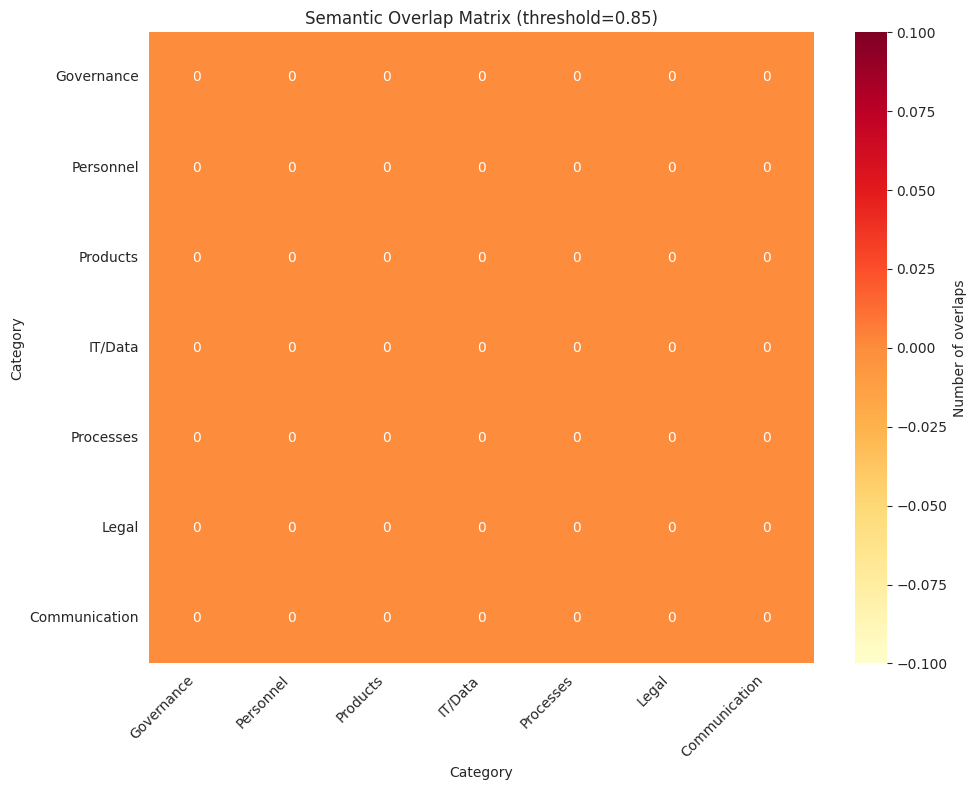


Total overlaps by category pair:


In [8]:
def create_overlap_matrix(semantic_overlaps, categories):
    """
    Create a matrix showing number of overlaps between each category pair.
    """
    n = len(categories)
    cat_to_idx = {cat: i for i, cat in enumerate(categories)}
    
    matrix = np.zeros((n, n), dtype=int)
    
    for cat1, _, cat2, _, _ in semantic_overlaps:
        i, j = cat_to_idx[cat1], cat_to_idx[cat2]
        matrix[i, j] += 1
        matrix[j, i] += 1  # Symmetric
    
    return matrix


# Create and visualize overlap matrix
categories = list(keyword_dict.keys())
overlap_matrix = create_overlap_matrix(semantic_overlaps, categories)

plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories,
            cbar_kws={'label': 'Number of overlaps'})
plt.title(f'Semantic Overlap Matrix (threshold={SIMILARITY_THRESHOLD})')
plt.xlabel('Category')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTotal overlaps by category pair:")
for i, cat1 in enumerate(categories):
    for j, cat2 in enumerate(categories):
        if i < j and overlap_matrix[i, j] > 0:
            print(f"  {cat1:20s} ↔ {cat2:20s}: {overlap_matrix[i, j]:2d} overlaps")

## 4. Detailed Overlap Report

In [9]:
print("=" * 80)
print("COMPREHENSIVE OVERLAP REPORT")
print("=" * 80)

print(f"\n📊 Summary:")
print(f"  Total categories: {len(categories)}")
print(f"  Total keywords: {sum(len(kws) for kws in keyword_dict.values())}")
print(f"  Exact overlaps: {len(exact_overlaps)}")
print(f"  Semantic overlaps (≥{SIMILARITY_THRESHOLD}): {len(semantic_overlaps)}")

if exact_overlaps or semantic_overlaps:
    print(f"\n⚠️  ACTION REQUIRED: Review and resolve overlaps")
    print(f"\n💡 Resolution strategies:")
    print(f"  1. Use include/exclude criteria to determine which category should keep the keyword")
    print(f"  2. Rephrase keywords to be more specific")
    print(f"  3. Remove genuinely ambiguous keywords from both categories")
    print(f"  4. Consider if overlap is acceptable (e.g., complementary aspects)")
else:
    print(f"\n✅ TAXONOMY IS CLEAN - No overlaps detected!")
    print(f"\nReady to proceed with:")
    print(f"  → Notebook 11: Get candidate synonyms")
    print(f"  → Notebook 12: Calculate similarities")
    print(f"  → Notebook 13: Preprocess dictionary")

COMPREHENSIVE OVERLAP REPORT

📊 Summary:
  Total categories: 7
  Total keywords: 74
  Exact overlaps: 0
  Semantic overlaps (≥0.85): 0

✅ TAXONOMY IS CLEAN - No overlaps detected!

Ready to proceed with:
  → Notebook 11: Get candidate synonyms
  → Notebook 12: Calculate similarities
  → Notebook 13: Preprocess dictionary


## 5. Export Recommendations

In [10]:
# Create recommendations dataframe
if semantic_overlaps:
    recommendations = []
    
    for cat1, kw1, cat2, kw2, sim in semantic_overlaps:
        # Get include/exclude criteria for both categories
        criteria1 = taxonomy_df[taxonomy_df['category'] == cat1][['include_criteria', 'exclude_criteria']].iloc[0]
        criteria2 = taxonomy_df[taxonomy_df['category'] == cat2][['include_criteria', 'exclude_criteria']].iloc[0]
        
        recommendations.append({
            'similarity': sim,
            'category_1': cat1,
            'keyword_1': kw1,
            'include_1': criteria1['include_criteria'],
            'exclude_1': criteria1['exclude_criteria'],
            'category_2': cat2,
            'keyword_2': kw2,
            'include_2': criteria2['include_criteria'],
            'exclude_2': criteria2['exclude_criteria']
        })
    
    recommendations_df = pd.DataFrame(recommendations)
    recommendations_df.to_csv('data/00_raw/taxonomy_overlap_recommendations.csv', index=False)
    
    print(f"✓ Saved overlap recommendations to: data/00_raw/taxonomy_overlap_recommendations.csv")
    print(f"\nReview this file and use include/exclude criteria to resolve overlaps.")
else:
    print("No overlaps to export - taxonomy is clean!")

No overlaps to export - taxonomy is clean!


## 6. Next Steps

**If overlaps were found:**
1. Review `taxonomy_overlap_recommendations.csv`
2. Manually edit `taxonomy_sheet_v2.csv` to resolve overlaps
3. Re-run this notebook to verify
4. Once clean, proceed to notebook 11

**If no overlaps:**
1. ✅ Taxonomy is validated
2. Proceed to notebook 11 (Get candidate synonyms)
3. Use `taxonomy_sheet_v2.csv` as input